## Pré-processing et Feature Engineering

## Chargement des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

pd.set_option("display.max_columns", None)

In [2]:
df_2014 = pd.read_csv(
    "../data/co2_2014.csv",
    encoding="latin1",
    sep=";"
)

df_2014.head()

,lib_mrq,lib_mod_doss,lib_mod,dscom,cnit,tvv,cod_cbr,hybride,puiss_admin_98,puiss_max,typ_boite_nb_rapp,conso_urb,conso_exurb,conso_mixte,co2,co_typ_1,hc,nox,hcnox,ptcl,masse_ordma_min,masse_ordma_max,champ_v9,date_maj,Carrosserie,gamme,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29
0,ALFA-ROMEO,159,159,159 1750 Tbi (200ch),M10ALFVP000G340,939AXN1B52C,ES,non,12,147,M 6,"11,30000019","5,800000191","7,800000191",182.0,"0,647000015","0,052000001","0,032000002",NaN,"0,002",1505,1505,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
1,ALFA-ROMEO,159,159,159 1750 Tbi (200ch),M10ALFVP000H341,939BXN1B53C,ES,non,12,147,M 6,"11,5",6,8,186.0,"0,647000015","0,052000001","0,032000002",NaN,"0,002",1555,1555,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
2,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000E302,939AXR1B64,GO,non,7,100,M 6,"6,599999905","4,199999809","5,099999905",134.0,"0,066",NaN,"0,149000004","0,174999997","0,001",1565,1565,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
3,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000F303,939AXR1B64B,GO,non,7,100,M 6,"6,599999905","4,199999809","5,099999905",134.0,"0,066",NaN,"0,149000004","0,174999997","0,001",1565,1565,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
4,ALFA-ROMEO,159,159,159 2.0 JTDm (170ch),M10ALFVP000G304,939AXS1B66,GO,non,9,125,M 6,"6,900000095","4,300000191","5,300000191",139.0,"0,059999999",NaN,"0,164000005","0,193000004","0,001",1565,1565,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN



## État initial du dataset

In [3]:

df_2014.shape

(55044, 30)

In [4]:
df_2014.info()

<class 'pandas.DataFrame'>
RangeIndex: 55044 entries, 0 to 55043
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   lib_mrq            55044 non-null  str    
 1   lib_mod_doss       55044 non-null  str    
 2   lib_mod            55044 non-null  str    
 3   dscom              55044 non-null  str    
 4   cnit               55044 non-null  str    
 5   tvv                55044 non-null  str    
 6   cod_cbr            55044 non-null  str    
 7   hybride            55044 non-null  str    
 8   puiss_admin_98     55044 non-null  int64  
 9   puiss_max          55044 non-null  str    
 10  typ_boite_nb_rapp  55044 non-null  str    
 11  conso_urb          55001 non-null  str    
 12  conso_exurb        55001 non-null  str    
 13  conso_mixte        55010 non-null  str    
 14  co2                55010 non-null  float64
 15  co_typ_1           54886 non-null  str    
 16  hc                 9773 non-null 

Le jeu de données contient 55 044 observations et 30 variables.

Les variables décrivent les caractéristiques techniques des véhicules homologués en France en 2014 : marque, modèle, type de carburant, puissance, consommation, masse, norme environnementale et émissions de CO₂.

Avant toute modélisation, une phase de prétraitement est réalisée afin de nettoyer les données, traiter les valeurs manquantes et préparer le jeu de données pour les étapes suivantes. Conformément aux bonnes pratiques, les transformations apprenant des informations à partir des données (imputation, encodage ou standardisation) seront ajustées uniquement sur le jeu d'entraînement avant d'être appliquées au jeu de test, afin d'éviter tout risque de data leakage.

## Analyse des valeurs manquantes

In [5]:
(df_2014.isnull().mean() * 100).sort_values(ascending=False)

Unnamed: 27          100.000000
Unnamed: 26          100.000000
Unnamed: 29          100.000000
Unnamed: 28          100.000000
date_maj              94.101083
hc                    82.245113
hcnox                 17.963811
ptcl                   4.865199
nox                    0.287043
co_typ_1               0.287043
champ_v9               0.110820
conso_urb              0.078119
conso_exurb            0.078119
conso_mixte            0.061769
co2                    0.061769
typ_boite_nb_rapp      0.000000
puiss_admin_98         0.000000
hybride                0.000000
cod_cbr                0.000000
dscom                  0.000000
cnit                   0.000000
tvv                    0.000000
lib_mod_doss           0.000000
lib_mrq                0.000000
lib_mod                0.000000
puiss_max              0.000000
masse_ordma_max        0.000000
masse_ordma_min        0.000000
gamme                  0.000000
Carrosserie            0.000000
dtype: float64

L'analyse des valeurs manquantes met en évidence plusieurs variables fortement incomplètes.

Les colonnes `Unnamed: 26` à `Unnamed: 29` sont entièrement vides, tandis que la variable `date_maj` présente plus de 94 % de valeurs manquantes. Parmi les variables environnementales, `hc` affiche plus de 82 % de données manquantes et `hcnox` près de 18 %.

À l'inverse, la majorité des autres variables sont quasiment complètes, avec moins de 1 % de valeurs manquantes.

Ces résultats permettent d'orienter les choix de prétraitement. Les variables très fortement incomplètes seront supprimées lorsqu'elles ne présentent pas d'intérêt pour la modélisation, tandis que les variables comportant peu de valeurs manquantes feront l'objet d'un traitement adapté afin de préserver un maximum d'informations.

## Suppression des colonnes vides et peu exploitables

In [6]:
colonnes_a_supprimer = [
    'Unnamed: 26',
    'Unnamed: 27',
    'Unnamed: 28',
    'Unnamed: 29',
    'date_maj'
]

df_2014 = df_2014.drop(columns=colonnes_a_supprimer)

df_2014.shape

(55044, 25)


Les colonnes Unnamed: 26 à Unnamed: 29 ont été supprimées car elles étaient entièrement vides et n'apportaient aucune information exploitable.

La variable date_maj a également été retirée du jeu de données. Avec plus de 94 % de valeurs manquantes et sans pouvoir explicatif direct pour la prédiction des émissions de CO₂, son exploitation apparaissait peu pertinente pour la suite du projet.

Le dataset passe ainsi de 30 à 25 variables, tout en conservant les 55 044 observations initiales.

## Traitement des variables fortement incomplètes

In [7]:
df_2014 = df_2014.drop(columns=['hc', 'hcnox'])

df_2014.shape

(55044, 23)

Les variables hc et hcnox présentent respectivement plus de 82 % et près de 18 % de valeurs manquantes.

La variable hc a été supprimée en raison de son très faible niveau de complétude, rendant toute imputation peu pertinente. La variable hcnox a également été retirée afin de simplifier le jeu de données et de privilégier des variables environnementales plus complètes et directement exploitables pour la modélisation.

La variable ptcl, bien qu'incomplète, a été conservée car son taux de valeurs manquantes reste limité (moins de 5 %) et elle conserve un intérêt potentiel pour l'analyse des émissions polluantes.

Le dataset passe ainsi de 25 à 23 variables.

## Conversion des variables numériques

Certaines variables quantitatives ont été importées sous forme de chaînes de caractères en raison de l'utilisation de la virgule comme séparateur décimal. Elles sont converties au format numérique afin de permettre les calculs statistiques, les traitements de prétraitement et les futures étapes de modélisation.

In [8]:
colonnes_numeriques = [
    'puiss_max',
    'conso_urb',
    'conso_exurb',
    'conso_mixte',
    'co_typ_1',
    'nox',
    'ptcl'
]

for col in colonnes_numeriques:
    df_2014[col] = (
        df_2014[col]
        .astype(str)
        .str.replace(',', '.', regex=False)
    )

    df_2014[col] = pd.to_numeric(df_2014[col], errors='coerce')

In [9]:
df_2014.info()

<class 'pandas.DataFrame'>
RangeIndex: 55044 entries, 0 to 55043
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   lib_mrq            55044 non-null  str    
 1   lib_mod_doss       55044 non-null  str    
 2   lib_mod            55044 non-null  str    
 3   dscom              55044 non-null  str    
 4   cnit               55044 non-null  str    
 5   tvv                55044 non-null  str    
 6   cod_cbr            55044 non-null  str    
 7   hybride            55044 non-null  str    
 8   puiss_admin_98     55044 non-null  int64  
 9   puiss_max          55044 non-null  float64
 10  typ_boite_nb_rapp  55044 non-null  str    
 11  conso_urb          55001 non-null  float64
 12  conso_exurb        55001 non-null  float64
 13  conso_mixte        55010 non-null  float64
 14  co2                55010 non-null  float64
 15  co_typ_1           54886 non-null  float64
 16  nox                54886 non-null

Les variables concernées ont été correctement converties au format numérique (float64), ce qui permettra leur utilisation dans les analyses statistiques et les algorithmes de modélisation.

Cette conversion a également permis d'identifier d'éventuelles valeurs invalides, désormais représentées sous forme de valeurs manquantes (NaN), qui seront traitées lors des étapes suivantes du prétraitement.

## Choix de la méthode d'imputation

Les variables ptcl, nox et co_typ_1 présentent un faible taux de valeurs manquantes (inférieur à 5 %). Afin de conserver l'ensemble des observations tout en limitant les biais liés aux données manquantes, plusieurs stratégies d'imputation ont été étudiées.

Une première approche consistait à réaliser une imputation par marque de véhicule. Cette solution n'a toutefois pas été retenue en raison de la forte disparité des effectifs entre les marques. Certaines sont représentées par plusieurs dizaines de milliers de véhicules, tandis que d'autres ne comptent que quelques dizaines d'observations, rendant les médianes calculées peu robustes pour les marques les moins représentées.

Une seconde approche reposait sur une imputation par type de carburant. Cette stratégie apparaît particulièrement pertinente pour certaines variables environnementales, les émissions polluantes étant directement liées à la motorisation des véhicules. Une analyse de la répartition des catégories de carburant, des effectifs associés et des médianes par carburant a donc été réalisée afin d'évaluer cette hypothèse.

Enfin, une troisième approche consistait à utiliser la médiane globale du jeu de données. Cette méthode simple et robuste permet de limiter l'influence des valeurs extrêmes tout en conservant l'ensemble des observations.

Les analyses réalisées montrent que les variables nox et co_typ_1 présentent des différences importantes selon le type de carburant, tandis que les médianes de ptcl restent très proches entre les principales catégories. En conséquence, une imputation conditionnelle par carburant a été retenue pour nox et co_typ_1, tandis qu'une imputation par la médiane globale a été privilégiée pour ptcl.

In [10]:
# Répartition des carburants
df_2014['cod_cbr'].value_counts()

cod_cbr
GO       49311
ES        5169
EH         298
GH          81
EL          34
ES/GN       32
GN/ES       32
ES/GP       23
GP/ES       23
GN          21
FE          10
EE           9
GL           1
Name: count, dtype: int64

In [11]:
# Médianes NOx par carburant
df_2014.groupby('cod_cbr')['nox'].median().sort_values()

cod_cbr
EE       0.003
EH       0.006
ES/GP    0.018
FE       0.020
GP/ES    0.026
ES       0.030
GN/ES    0.031
GN       0.032
ES/GN    0.036
GL       0.036
GH       0.061
GO       0.214
EL         NaN
Name: nox, dtype: float64

In [12]:
# Médianes PTCL par carburant
df_2014.groupby('cod_cbr')['ptcl'].median().sort_values()

cod_cbr
GL       0.000
EE       0.001
ES       0.001
EH       0.001
FE       0.001
GH       0.001
GO       0.001
GN       0.007
EL         NaN
ES/GN      NaN
ES/GP      NaN
GN/ES      NaN
GP/ES      NaN
Name: ptcl, dtype: float64

In [13]:
# Médianes CO par carburant
df_2014.groupby('cod_cbr')['co_typ_1'].median().sort_values()

cod_cbr
GL       0.020
GO       0.100
EE       0.132
EH       0.187
GH       0.222
ES       0.238
GN/ES    0.258
ES/GN    0.305
ES/GP    0.360
GN       0.370
GP/ES    0.382
FE       0.632
EL         NaN
Name: co_typ_1, dtype: float64

In [14]:
df_2014.groupby('cod_cbr')[['nox', 'co_typ_1']].count()

,nox,co_typ_1
cod_cbr,,
EE,9,9
EH,298,298
EL,0,0
ES,5096,5096
ES/GN,20,20
ES/GP,23,23
FE,10,10
GH,81,81
GL,1,1


## Analyse des résultats

L'analyse des médianes par carburant met en évidence des différences importantes pour les variables nox et co_typ_1, notamment entre les véhicules diesel (GO) et essence (ES).

Pour la variable nox, la médiane observée pour les véhicules diesel (0,214) est significativement supérieure à celle des véhicules essence (0,030). Une différence notable est également observée pour co_typ_1, avec des médianes respectives de 0,100 pour le diesel et 0,238 pour l'essence.

À l'inverse, les médianes de ptcl sont quasiment identiques quel que soit le carburant considéré, ce qui suggère une faible influence de cette variable de regroupement.

Les catégories principales (GO et ES) disposent d'effectifs très élevés, garantissant la robustesse des médianes calculées. À l'inverse, certaines catégories très peu représentées (par exemple GL, FE ou EE) doivent être interprétées avec davantage de prudence. Enfin, la catégorie EL ne comporte aucune valeur disponible pour les variables nox et co_typ_1.

Ces résultats justifient le recours à une imputation conditionnelle par carburant pour les variables nox et co_typ_1, tandis qu'une imputation par la médiane globale est conservée pour ptcl.

Conformément aux bonnes pratiques de prétraitement, cette stratégie d'imputation sera appliquée uniquement après la séparation des jeux d'entraînement et de test, afin d'éviter tout risque de data leakage.

## Analyse des modalités rares

In [15]:
df_2014['lib_mrq'].value_counts(normalize=True) * 100

lib_mrq
MERCEDES        65.801904
VOLKSWAGEN      24.836494
FIAT             0.930165
BMW              0.841145
OPEL             0.724875
LEXUS            0.654022
AUDI             0.634038
FORD             0.541385
NISSAN           0.523218
CITROEN          0.399680
ALFA-ROMEO       0.332461
PEUGEOT          0.316111
RENAULT          0.290677
TOYOTA           0.254342
SKODA            0.237991
MINI             0.227091
PORSCHE          0.198023
SEAT             0.196207
VOLVO            0.196207
ASTON MARTIN     0.141705
CHEVROLET        0.138071
JEEP             0.134438
LAND ROVER       0.134438
KIA              0.121721
LANCIA           0.105370
HONDA            0.101737
SMART            0.094470
HYUNDAI          0.092653
MITSUBISHI       0.079936
MAZDA            0.074486
JAGUAR           0.070852
CADILLAC         0.069036
LAMBORGHINI      0.065402
DACIA            0.052685
SUZUKI           0.052685
BENTLEY          0.047235
FERRARI          0.045418
MASERATI         0.043601
SUBA

L'analyse de la variable lib_mrq met en évidence la présence de nombreuses modalités rares représentant moins de 0,5 % des observations. Compte tenu de l'objectif de ce premier prétraitement, aucune fusion de modalités n'a été réalisée à ce stade. Cette transformation pourra être envisagée ultérieurement si la variable est retenue pour la modélisation.

## Création de nouvelles variables

In [16]:
df_2014['rapport_puissance_masse'] = (
    df_2014['puiss_max'] /
    df_2014['masse_ordma_min']
)

In [17]:
df_2014['rapport_puissance_masse'].describe()

count    55044.000000
mean         0.057802
std          0.024929
min          0.010776
25%          0.045746
50%          0.052016
75%          0.059259
max          0.373802
Name: rapport_puissance_masse, dtype: float64

In [18]:
df_2014[['rapport_puissance_masse', 'co2']].corr()

,rapport_puissance_masse,co2
rapport_puissance_masse,1.00000,0.08878
co2,0.08878,1.00000


La corrélation linéaire observée entre cette variable et les émissions de CO₂ reste faible (0,089). Dans le cadre de cette première approche, cette variable n'apporte pas de gain explicatif suffisant et n'a donc pas été retenue pour la suite du prétraitement.

## Décision retenue

In [19]:
df_2014.drop(columns=['rapport_puissance_masse'], inplace=True)

## Vérification

In [20]:
'rapport_puissance_masse' in df_2014.columns

False

La faible corrélation observée avec les émissions de CO₂ (≈ 0,089) ne justifie pas le maintien de cette variable dans le jeu de données. La vérification confirme qu'elle a bien été supprimée avant les étapes de modélisation.

In [21]:
# Création du ratio puissance / masse maximale
df_2014["rapport_puissance_masse_max"] = (
    df_2014["puiss_max"] / df_2014["masse_ordma_max"]
)

In [22]:
df_2014["rapport_puissance_masse_max"].describe()

count    55044.000000
mean         0.053289
std          0.026310
min          0.010776
25%          0.040340
50%          0.046154
75%          0.057637
max          0.373802
Name: rapport_puissance_masse_max, dtype: float64

In [23]:
df_2014[["rapport_puissance_masse_max", "co2"]].corr()

,rapport_puissance_masse_max,co2
rapport_puissance_masse_max,1.000000,0.053839
co2,0.053839,1.000000


Un second ratio basé sur la masse maximale du véhicule (puiss_max / masse_ordma_max) a également été évalué. La corrélation linéaire observée avec les émissions de CO₂ (0,054) étant encore plus faible que celle obtenue avec la masse minimale, cette variable n'a pas été retenue pour la suite du prétraitement.

## Décision retenue

In [24]:
df_2014.drop(columns=["rapport_puissance_masse_max"], inplace=True)

## Vérification

In [25]:
"rapport_puissance_masse_max" in df_2014.columns

False

## Détection des valeurs aberrantes

Les valeurs aberrantes (outliers) correspondent à des observations dont les valeurs s'écartent fortement du reste de la distribution.

Leur identification est importante car elles peuvent influencer les analyses statistiques et les performances des modèles de machine learning. Dans le cas présent, l'objectif est d'identifier les éventuelles valeurs extrêmes présentes dans les principales variables quantitatives du dataset afin d'évaluer leur pertinence métier avant toute décision de traitement.

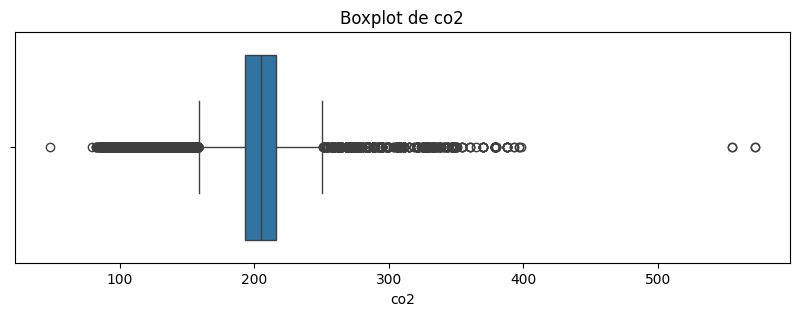

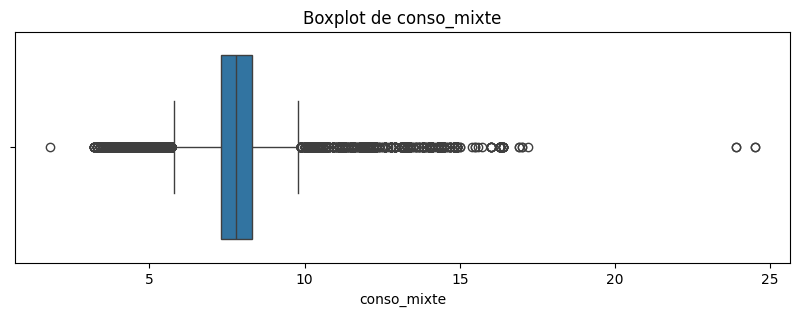

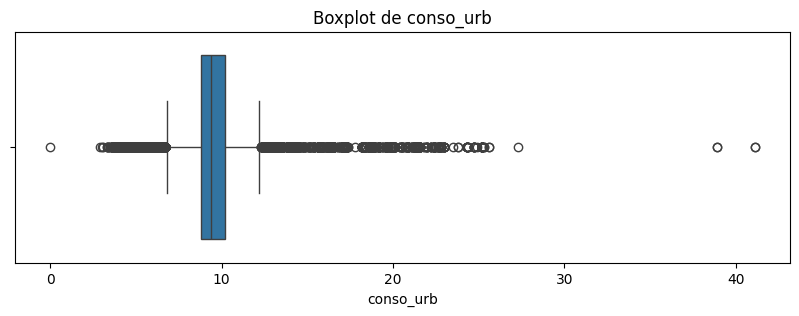

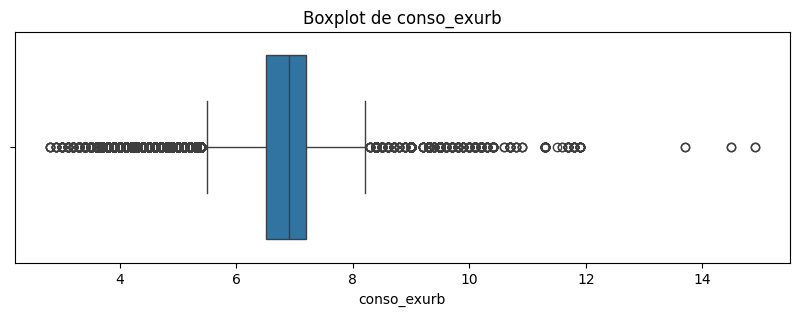

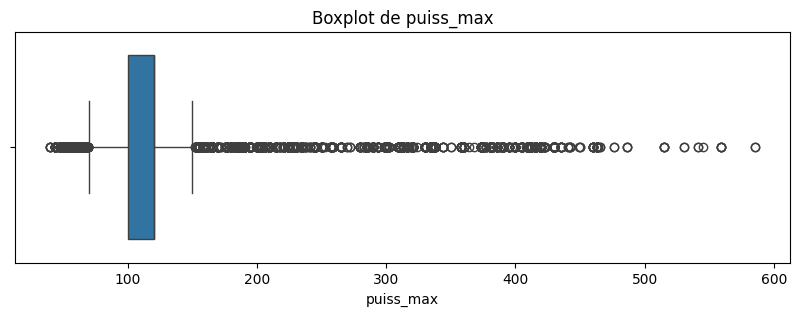

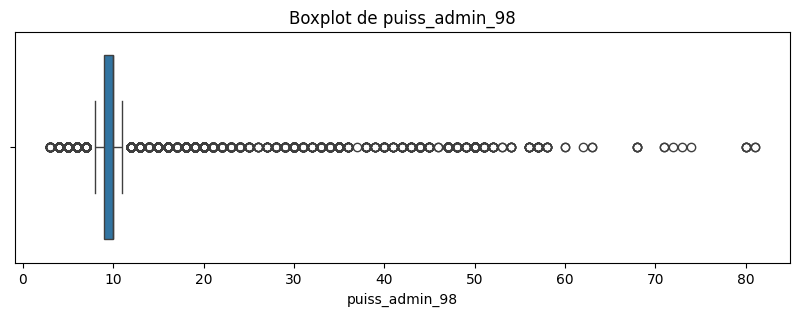

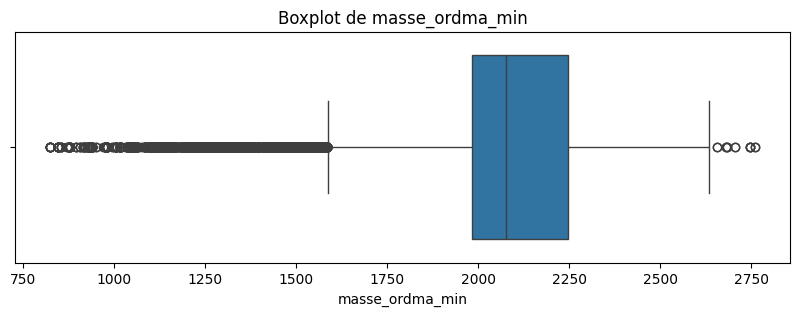

In [38]:
colonnes_numeriques = [
    'co2',
    'conso_mixte',
    'conso_urb',
    'conso_exurb',
    'puiss_max',
    'puiss_admin_98',
    'masse_ordma_min'
]

for col in colonnes_numeriques:
    plt.figure(figsize=(10, 3))
    sns.boxplot(x=df_2014[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

L'analyse des boxplots met en évidence la présence de nombreuses valeurs extrêmes sur plusieurs variables quantitatives, notamment les consommations, la puissance et les émissions de CO₂.

Après analyse, ces observations apparaissent cohérentes d'un point de vue métier et correspondent vraisemblablement à des véhicules atypiques (véhicules sportifs, haut de gamme ou fortement motorisés) plutôt qu'à des erreurs de saisie.

Aucune suppression de valeurs aberrantes n'a donc été réalisée. Les observations ont été conservées afin de préserver la représentativité du parc automobile étudié.

## Encodage des variables catégorielles

In [39]:
variables_cat = [
    'lib_mrq',
    'lib_mod_doss',
    'lib_mod',
    'dscom',
    'cnit',
    'tvv',
    'cod_cbr',
    'hybride',
    'Carrosserie',
    'gamme'
]

for col in variables_cat:
    print(f"\n{col}")
    print(df_2014[col].nunique())


lib_mrq
44

lib_mod_doss
470

lib_mod
423

dscom
3809

cnit
54924

tvv
35379

cod_cbr
11

hybride
2

Carrosserie
11

gamme
7


Une analyse du nombre de modalités a été réalisée sur les variables catégorielles du jeu de données.

Les variables cnit, tvv, dscom, lib_mod et lib_mod_doss présentent un très grand nombre de modalités et correspondent principalement à des identifiants ou références techniques propres aux véhicules. Leur encodage entraînerait une forte augmentation de la dimension du dataset sans garantie d'amélioration des performances prédictives.

À l'inverse, les variables cod_cbr, hybride, Carrosserie et gamme présentent un nombre limité de modalités et constituent des candidates pertinentes pour un futur encodage lors de la phase de modélisation.

## Standardisation des variables numériques

Les principales variables numériques du dataset ont été identifiées et préparées pour une future phase de modélisation. La standardisation n'a pas été appliquée à ce stade du projet car elle doit être réalisée après la séparation des jeux d'entraînement et de test afin d'éviter toute fuite d'information.

Cette transformation sera intégrée au pipeline de prétraitement lors de l'étape de modélisation pour les algorithmes qui y sont sensibles, tels que les régressions linéaires, les méthodes à noyau ou les algorithmes basés sur les distances.

## Ancienne version de l'imputation (à remplacer)

In [22]:
df_2014['ptcl'] = df_2014['ptcl'].fillna(df_2014['ptcl'].median())

df_2014['nox'] = (
    df_2014.groupby('cod_cbr')['nox']
           .transform(lambda x: x.fillna(x.median()))
)

df_2014['co_typ_1'] = (
    df_2014.groupby('cod_cbr')['co_typ_1']
           .transform(lambda x: x.fillna(x.median()))
)

In [23]:
df_2014[['ptcl', 'nox', 'co_typ_1']].isnull().sum()

ptcl        0
nox         0
co_typ_1    0
dtype: int64

Les valeurs manquantes des variables environnementales ont été imputées selon la méthode retenue. Aucune valeur manquante ne subsiste désormais pour les variables ptcl, nox et co_typ_1.

## Traitement des valeurs manquantes restantes

In [ ]:
df_2014.isnull().sum().sort_values(ascending=False).head(10)

lib_mrq           0
lib_mod_doss      0
lib_mod           0
dscom             0
cnit              0
tvv               0
cod_cbr           0
hybride           0
puiss_admin_98    0
puiss_max         0
dtype: int64

Après l'imputation des variables environnementales et la suppression des observations incomplètes, aucune valeur manquante ne subsiste dans le jeu de données.

Le dataset est désormais complet et prêt pour les étapes suivantes du prétraitement, notamment l'encodage des variables catégorielles, la standardisation des variables numériques et le traitement des valeurs aberrantes.

## État final du dataset après pré-processing

In [ ]:
df_2014.shape

(54974, 23)

Le dataset est désormais propre, cohérent et prêt pour les prochaines étapes du prétraitement, notamment l'encodage des variables catégorielles, la détection des valeurs aberrantes et la préparation à la modélisation des émissions de CO₂.